In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader,TensorDataset
import torch.optim as optim

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving digits_dl_practice.csv to digits_dl_practice.csv


In [ ]:
df = pd.read_csv("digits_dl_practice.csv")

In [ ]:
df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
df.shape

(1797, 65)

In [ ]:
df['target'].value_counts()

,count
target,
3,183
1,182
5,182
4,181
6,181
9,180
7,179
0,178
2,177


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pixel_0   1797 non-null   float64
 1   pixel_1   1797 non-null   float64
 2   pixel_2   1797 non-null   float64
 3   pixel_3   1797 non-null   float64
 4   pixel_4   1797 non-null   float64
 5   pixel_5   1797 non-null   float64
 6   pixel_6   1797 non-null   float64
 7   pixel_7   1797 non-null   float64
 8   pixel_8   1797 non-null   float64
 9   pixel_9   1797 non-null   float64
 10  pixel_10  1797 non-null   float64
 11  pixel_11  1797 non-null   float64
 12  pixel_12  1797 non-null   float64
 13  pixel_13  1797 non-null   float64
 14  pixel_14  1797 non-null   float64
 15  pixel_15  1797 non-null   float64
 16  pixel_16  1797 non-null   float64
 17  pixel_17  1797 non-null   float64
 18  pixel_18  1797 non-null   float64
 19  pixel_19  1797 non-null   float64
 20  pixel_20  1797 non-null   floa

In [ ]:
df.describe()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

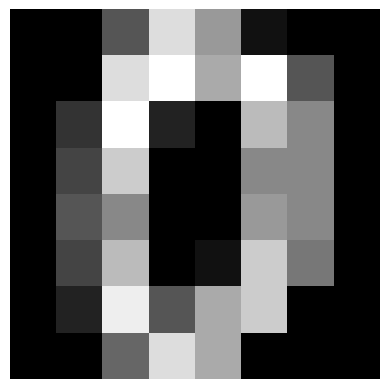

In [ ]:
image=df.drop('target',axis=1).iloc[0].values   #iloc means take first row.
image = image.reshape(8,8)  #from 64 pixels to 8*8
plt.imshow(image, cmap="gray")  #displays
plt.axis("off")  #turns off x_axis and y_axis
plt.show()

In [ ]:
x = df.drop('target',axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#normalise pixelvalues

x_train = x_train/16
x_test = x_test/16

In [ ]:
#convert the values to torch tensor ..to get in a numerical structure..using 32 bit decimal works with nn usually..and long is type of int type..

x_train =torch.tensor(x_train.values,dtype=torch.float32)
x_test = torch.tensor(x_test.values,dtype=torch.float32)
y_train = torch.tensor(y_train.values,dtype=torch.long)
y_test = torch.tensor(y_test.values,dtype=torch.long)

In [ ]:
train_dataset = TensorDataset(x_train,y_train)
test_dataset= TensorDataset(x_test,y_test)

In [ ]:
# dataloader.
train_loader = DataLoader(
    train_dataset,batch_size=64,shuffle=True
)


In [ ]:
test_loader =DataLoader(test_dataset,batch_size=64,shuffle=False)

In [ ]:
print(x_train.shape)
print(y_train.shape)

torch.Size([1437, 64])
torch.Size([1437])


In [ ]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(64, 128),  # linear is connected to previous layers.
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
loss_function = nn.CrossEntropyLoss()

In [ ]:
model = NeuralNetwork()

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10

for epoch in range(epochs):

    for images, labels in train_loader:

        outputs = model(images)   #This sends the images through our neural network.

        loss = loss_function(outputs, labels)   #How wrong were the model's predictions compared with the actual labels?

        optimizer.zero_grad()  #Before calculating new weight updates, clear the old gradient information.

        loss.backward()  #How should each weight change to reduce the loss?

        optimizer.step()  #updates the weights.

    print("Epoch:", epoch + 1, "Loss:", loss.item())

Epoch: 1 Loss: 2.022646427154541
Epoch: 2 Loss: 1.7086701393127441
Epoch: 3 Loss: 1.253955602645874
Epoch: 4 Loss: 0.8682243227958679
Epoch: 5 Loss: 0.6917909383773804
Epoch: 6 Loss: 0.4802311658859253
Epoch: 7 Loss: 0.4284626543521881
Epoch: 8 Loss: 0.30926769971847534
Epoch: 9 Loss: 0.34849634766578674
Epoch: 10 Loss: 0.24431635439395905


In [ ]:
# #Give images to model
#         ↓
# 2. Get prediction
#         ↓
# 3. Calculate loss
#         ↓
# 4. Backpropagation
#         ↓
# 5. Update weights
#         ↓
# 6. Next batch


In [ ]:
model.eval()   # Means: "Now I'm testing."

with torch.no_grad():
    outputs = model(x_test)   ## Model looks at all test images and gives its outputs.
    _, predictions = torch.max(outputs, 1)    #For each image, choose the digit with the highest output.

accuracy = (predictions == y_test).float().mean()    #Then calculate the percentage of correct predictions

print("Accuracy:", accuracy.item())

Accuracy: 0.9333333373069763


In [ ]:
image = x_test[0]

model.eval()

with torch.no_grad():
    output = model(image.unsqueeze(0))
    _, prediction = torch.max(output, 1)

print("Predicted:", prediction.item())
print("Actual:", y_test[0].item())

Predicted: 6
Actual: 6
